missing values
join and merge 
aggregation
time-series analysis
final business report

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (11, 5)

# ────────────────────────────────────────────────────────────────────
# SWITCH BETWEEN REAL OLIST DATA AND SYNTHETIC DATA
# ────────────────────────────────────────────────────────────────────
USE_REAL_DATA = True   # set to True if you've downloaded Olist from Kaggle
DATA_DIR = 'dataset/'  # folder containing the Olist CSVs (real data only)

print(f"USE_REAL_DATA = {USE_REAL_DATA}")
print(f"pandas = {pd.__version__}")


USE_REAL_DATA = True
pandas = 2.3.3


In [2]:
customers      = pd.read_csv(DATA_DIR + 'olist_customers_dataset.csv')
orders         = pd.read_csv(DATA_DIR + 'olist_orders_dataset.csv')
order_items    = pd.read_csv(DATA_DIR + 'olist_order_items_dataset.csv')
products       = pd.read_csv(DATA_DIR + 'olist_products_dataset.csv')
sellers        = pd.read_csv(DATA_DIR + 'olist_sellers_dataset.csv')
payments       = pd.read_csv(DATA_DIR + 'olist_order_payments_dataset.csv')
reviews        = pd.read_csv(DATA_DIR + 'olist_order_reviews_dataset.csv')
translation    = pd.read_csv(DATA_DIR + 'product_category_name_translation.csv')

# Parse datetime columns up front
for col in ['order_purchase_timestamp','order_approved_at',
            'order_delivered_carrier_date','order_delivered_customer_date',
            'order_estimated_delivery_date']:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

reviews['review_creation_date']     = pd.to_datetime(reviews['review_creation_date'])
reviews['review_answer_timestamp']  = pd.to_datetime(reviews['review_answer_timestamp'], errors='coerce')
order_items['shipping_limit_date']  = pd.to_datetime(order_items['shipping_limit_date'])

print('All 8 tables loaded:')
for name, t in [('customers',customers),('orders',orders),('order_items',order_items),
                ('products',products),('sellers',sellers),('payments',payments),
                ('reviews',reviews),('translation',translation)]:
    print(f'  {name:15s} {t.shape}')

All 8 tables loaded:
  customers       (3000, 5)
  orders          (7000, 8)
  order_items     (8593, 7)
  products        (800, 9)
  sellers         (250, 4)
  payments        (7139, 5)
  reviews         (5963, 7)
  translation     (16, 2)


### Q1.1 — Display the first 5 rows of every table.

In [110]:
df1 = pd.read_csv('./dataset/olist_customers_dataset.csv')
df2 = pd.read_csv('./dataset/olist_order_items_dataset.csv')
df3 = pd.read_csv('./dataset/olist_order_payments_dataset.csv')
df4 = pd.read_csv('./dataset/olist_order_reviews_dataset.csv')
df5 = pd.read_csv('./dataset/olist_orders_dataset.csv')
df6 = pd.read_csv('./dataset/olist_products_dataset.csv')
df7 = pd.read_csv('./dataset/olist_sellers_dataset.csv')
df8 = pd.read_csv('./dataset/product_category_name_translation.csv')

In [4]:
df = [df1, df2, df3, df4, df5, df6, df7, df8]

In [5]:
df = [df1, df2, df3, df4, df5, df6, df7, df8]
for i , data in enumerate(df, start=1):
    print(f"% rows of table {i}")
    print(data.head(5))

% rows of table 1
   customer_id customer_unique_id  customer_zip_code_prefix customer_city customer_state
0  cust_000000        uniq_001578                     45150      londrina             PR
1  cust_000001        uniq_002114                      2866       niteroi             RJ
2  cust_000002        uniq_001632                     67639      salvador             BA
3  cust_000003        uniq_001514                     46046  porto alegre             RS
4  cust_000004        uniq_001191                     77383        santos             SP
% rows of table 2
     order_id  order_item_id  product_id  seller_id  shipping_limit_date   price  freight_value
0  ord_000000              1  prod_00658  sell_0139  2018-10-18 18:44:00  115.30          19.73
1  ord_000000              2  prod_00707  sell_0165  2018-10-19 18:44:00   75.39           4.15
2  ord_000001              1  prod_00063  sell_0188  2018-09-03 15:38:00   94.17          18.35
3  ord_000001              2  prod_00154  sell

### Q1.2 — For each table, print `.shape`, `.dtypes`, and `.info()`.

In [6]:
df1.shape

(3000, 5)

In [7]:
df1.dtypes

customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object
dtype: object

In [8]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               3000 non-null   object
 1   customer_unique_id        3000 non-null   object
 2   customer_zip_code_prefix  3000 non-null   int64 
 3   customer_city             3000 non-null   object
 4   customer_state            3000 non-null   object
dtypes: int64(1), object(4)
memory usage: 117.3+ KB


In [9]:
df2.shape

(8593, 7)

In [10]:
df2.dtypes

order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object

In [11]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8593 entries, 0 to 8592
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   order_id             8593 non-null   object 
 1   order_item_id        8593 non-null   int64  
 2   product_id           8593 non-null   object 
 3   seller_id            8593 non-null   object 
 4   shipping_limit_date  8593 non-null   object 
 5   price                8593 non-null   float64
 6   freight_value        8593 non-null   float64
dtypes: float64(2), int64(1), object(4)
memory usage: 470.1+ KB


In [12]:
df3.shape

(7139, 5)

In [13]:
df3.dtypes

order_id                 object
payment_sequential        int64
payment_type             object
payment_installments      int64
payment_value           float64
dtype: object

In [14]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7139 entries, 0 to 7138
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              7139 non-null   object 
 1   payment_sequential    7139 non-null   int64  
 2   payment_type          7139 non-null   object 
 3   payment_installments  7139 non-null   int64  
 4   payment_value         7139 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 279.0+ KB


In [15]:

df4.shape

(5963, 7)

In [16]:
df4.dtypes

review_id                  object
order_id                   object
review_score                int64
review_comment_title       object
review_comment_message     object
review_creation_date       object
review_answer_timestamp    object
dtype: object

In [17]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5963 entries, 0 to 5962
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                5963 non-null   object
 1   order_id                 5963 non-null   object
 2   review_score             5963 non-null   int64 
 3   review_comment_title     3260 non-null   object
 4   review_comment_message   3330 non-null   object
 5   review_creation_date     5963 non-null   object
 6   review_answer_timestamp  4219 non-null   object
dtypes: int64(1), object(6)
memory usage: 326.2+ KB


In [18]:
df5.shape
df5.dtypes
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       7000 non-null   object
 1   customer_id                    7000 non-null   object
 2   order_status                   7000 non-null   object
 3   order_purchase_timestamp       7000 non-null   object
 4   order_approved_at              6965 non-null   object
 5   order_delivered_carrier_date   6639 non-null   object
 6   order_delivered_customer_date  6448 non-null   object
 7   order_estimated_delivery_date  7000 non-null   object
dtypes: object(8)
memory usage: 437.6+ KB


### Q1.3 — Identify keys
For each table, write down (as a markdown comment in a cell below) what the **primary key** is and what **foreign keys** link it to other tables.

For example, in `orders`:
- Primary key: `order_id`
- Foreign keys: `customer_id` → `customers`

`Customers` : 
- customer_id (primary key)

`Orders` : 
- Order_id (primary key)
- Customer_id (foreign key)

`Reviews` : 
- order_id (foreign key)

`Order_Items` : 
- order_id (foreign key)
- Product_id (foreign key)
- seller_id (foreign key)

`Payments` : 
- order_id (foreign key)

`products `: 
- product_id (primary key)

`Sellers` : 
- Seller_id (foreign key)

### Q1.4 — How many unique customers, sellers, products, and orders are there?
Use `.nunique()` rather than `len()` — they differ if a table has duplicates.

In [19]:
df1.nunique()

customer_id                 3000
customer_unique_id          1767
customer_zip_code_prefix    2966
customer_city                 36
customer_state                15
dtype: int64

In [20]:
df2.nunique()

order_id               7000
order_item_id             3
product_id              800
seller_id               250
shipping_limit_date    8230
price                  6780
freight_value          3132
dtype: int64

In [21]:
df5.nunique()

order_id                         7000
customer_id                      2711
order_status                        5
order_purchase_timestamp         6952
order_approved_at                6938
order_delivered_carrier_date     6603
order_delivered_customer_date    6423
order_estimated_delivery_date    6959
dtype: int64

In [22]:
df6.nunique()

product_id                    800
product_category_name          16
product_name_lenght            60
product_description_lenght    701
product_photos_qty              7
product_weight_g              772
product_length_cm              90
product_height_cm              78
product_width_cm               75
dtype: int64

### Q1.5 — What date range does the dataset cover?
Compute the min and max of `order_purchase_timestamp` and the total span in days.

In [23]:
df5['order_purchase_timestamp'] = pd.to_datetime(df5['order_purchase_timestamp'])

- to make sure the order_purchase_datetime is a date type

In [24]:
min_date = df5['order_purchase_timestamp'].min()
max_date = df5['order_purchase_timestamp'].max()

span_days = (max_date - min_date).days


- then compute the min_date and max_date . also the span_date

In [25]:
print(f"the minimum date is {min_date}")
print(f"the maximum date is {max_date}")
print(f"the spand days is {span_days}")

the minimum date is 2017-01-01 10:08:00
the maximum date is 2018-12-31 21:44:00
the spand days is 729


### Q1.6 — Memory usage
Compute the **total memory** used by all 8 DataFrames combined. Which table uses the most memory?

In [26]:
df1.memory_usage().sum()

np.int64(120132)

In [27]:
memory_usuage = {
    "customers" : df1.memory_usage().sum(),
    "orders" : df2.memory_usage().sum(),
    "reviews" : df3.memory_usage().sum(),
    "order_items" : df4.memory_usage().sum(),
    "payments" : df5.memory_usage().sum(),
    "products" : df6.memory_usage().sum(),
    "sellers" : df7.memory_usage().sum(),
    "translation" : df8.memory_usage().sum(),
}

- i created a dict with the csv file name. so, that it is easy as dict have the values and the key.

In [28]:
memory_df = pd.DataFrame(memory_usuage.items(), columns=["dataframes", "memory"])
memory_df

,dataframes,memory
0,customers,120132
1,orders,481340
2,reviews,285692
3,order_items,334060
4,payments,448132
5,products,57732
6,sellers,8132
7,translation,388


In [29]:
type(memory_df)

pandas.core.frame.DataFrame

- then memory_usuage.items() creates a pair with dataframes and memory
- dataframes and memory
- customers      120132
- order_items    500000
- orders         300000

- then pandas creates a table 

In [30]:
most_memory_table = memory_df.loc[memory_df["memory"].idxmax()]

print("Table using the most memory:", most_memory_table["dataframes"])
print("Memory used:", most_memory_table["memory"], "bytes")

Table using the most memory: orders
Memory used: 481340 bytes


### Q1.7 — Order status distribution
What are the unique values of `order_status` in the orders table, and how many rows fall into each? Sort by count, descending. What proportion of orders were ultimately delivered?

In [31]:
# Count each unique order status
status_counts = df5["order_status"].value_counts()

status_counts

order_status
delivered     6448
canceled       224
shipped        191
invoiced        72
processing      65
Name: count, dtype: int64

In [32]:
delivered_proportion = (
    status_counts["delivered"] / status_counts.sum()
)

print("Proportion delivered:", delivered_proportion)
print("Percentage delivered:", delivered_proportion * 100, "%")

Proportion delivered: 0.9211428571428572
Percentage delivered: 92.11428571428571 %


---
# Part 2 — Handling Missing Values

> **Rubric:** for every column that has missing values, you should be able to justify *why* it's missing and *what* you do about it. There is no single right answer — context matters.

### Q2.1 — Build a missing-value summary
Produce a DataFrame with one row per (table, column) pair where missing values exist. Columns: `table`, `column`, `n_missing`, `pct_missing`. Sort descending by `pct_missing`.

In [33]:
df1.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [34]:
df_missing = {
    "customers" : df1,
    "orders" : df2,
    "order_items" : df3,
    "products" : df4,
    "sellers" : df5,
    "payments" : df6,
    "reviews" : df7,
    "translation" : df8,
}

miss_columns = []

for table, frame in df_missing.items():
    miss = frame.isna().sum()
    for col, item in miss[miss > 0].items():
        miss_columns.append({
            "table" : table,
            "column" : col,
            "n_missing" : item,
            "pct_missing" :  item / len(frame) * 100
        })
df_columns = pd.DataFrame(miss_columns).sort_values('n_missing',ascending=False)
df_columns


,table,column,n_missing,pct_missing
0,products,review_comment_title,2703,45.329532
1,products,review_comment_message,2633,44.155626
2,products,review_answer_timestamp,1744,29.247023
5,sellers,order_delivered_customer_date,552,7.885714
4,sellers,order_delivered_carrier_date,361,5.157143
3,sellers,order_approved_at,35,0.500000
6,payments,product_category_name,24,3.000000
7,payments,product_weight_g,24,3.000000
8,payments,product_length_cm,24,3.000000
9,payments,product_height_cm,24,3.000000


### Q2.2 — Visualize the missing-value pattern in `orders`
Build a heatmap of `orders.isna()`. Comment on what you see.

In [48]:
df2.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value'], dtype='object')

In [52]:
df2.isna().sum()

order_id               1
order_item_id          3
product_id             3
seller_id              2
shipping_limit_date    5
price                  2
freight_value          4
dtype: int64

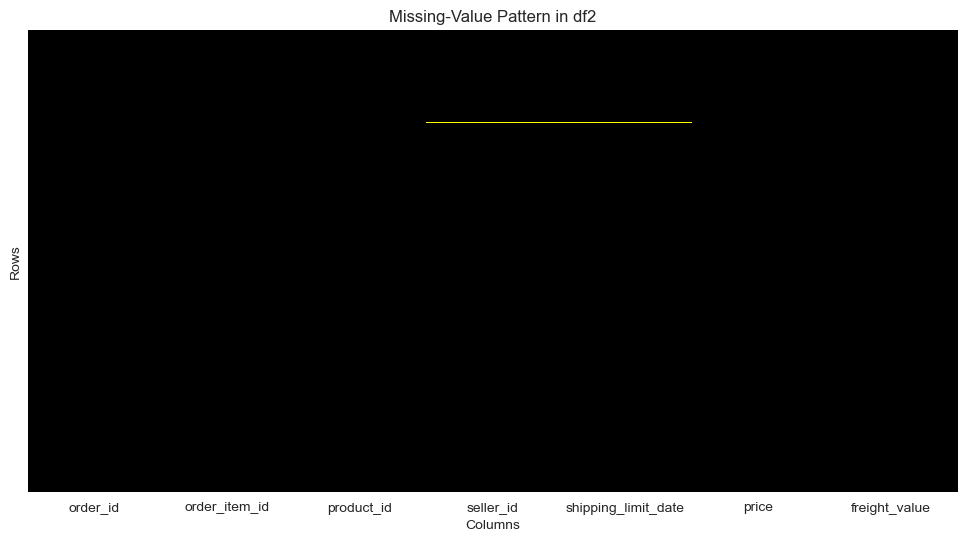

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

plt.figure(figsize=(12, 6))

sns.heatmap(
    df2.isna(),
    cbar=False,
    yticklabels=False,
    cmap=ListedColormap(["black", "yellow"])
)

plt.title("Missing-Value Pattern in df2")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

### Q2.3 — Explain the missingness in `orders.order_delivered_customer_date`
Group the orders DataFrame by `order_status` and count how many rows have `order_delivered_customer_date` missing for each status. Write a one-sentence interpretation: **why** would non-delivered orders have a missing delivery date?

In [37]:
df5.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [53]:
df2.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value'], dtype='object')

# sql
- SELECT order_delivered_customer_date AS missing_delivery_by_status 
- FROM ORDERS
- SUM (
    CASE (
        if insa > 0 include
        else dont include
    )
)
- GROUP BY (Order_status)
- ORDER BY ()

In [ ]:
missing_delivery_by_status = (
    df5['order_delivered_customer_date']
    .isna()
    .groupby(df5['order_status'])
    .sum()
    .sort_values(ascending=False)
)

missing_delivery_by_status

order_status
canceled      224
shipped       191
invoiced       72
processing     65
delivered       0
Name: order_delivered_customer_date, dtype: int64

Interpretation: Non-delivered orders have a missing order_delivered_customer_date because the order was cancelled, unavailable, still processing, or otherwise never reached the customer, so no actual delivery date was recorded.

### Q2.4 — Impute `order_approved_at`
A small number of rows have a missing `order_approved_at` despite being delivered. Impute these with the **mean approval delay** (mean of `order_approved_at - order_purchase_timestamp`) added to the purchase timestamp. Verify there are no more missing approved-at values among delivered orders afterwards.

In [60]:
df5.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [71]:
df5.isna().sum()

order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                 63
order_delivered_carrier_date     361
order_delivered_customer_date    552
order_estimated_delivery_date      0
dtype: int64

In [ ]:
df5['order_approved_at'] = pd.to_datetime(df5['order_approved_at'])
df5['order_purchase_timestamp'] = pd.to_datetime(df5['order_purchase_timestamp'])

In [99]:
mean_approval_delay = (df5['order_approved_at']) - (df5['order_purchase_timestamp'])

In [103]:
mean_approval_delay = mean_approval_delay.mean()

In [104]:
df5['order_approved_at'] = df5['order_approved_at'].fillna(mean_approval_delay)

In [105]:
df5.isna().sum()

order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date     361
order_delivered_customer_date    552
order_estimated_delivery_date      0
dtype: int64

In [106]:
df5.dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date            object
order_estimated_delivery_date            object
dtype: object

### Q2.5 — Decide what to do about missing `product_category_name`
A few products are missing their category name. Show how many. Pick one of these strategies and apply it:
- (a) Fill with `'unknown'`
- (b) Drop those rows
- (c) Impute based on similar products (advanced)

Justify your choice in a comment.

In [112]:
df6.columns

Index(['product_id', 'product_category_name', 'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm'],
      dtype='object')

In [113]:
df6.isna().sum()

product_id                     0
product_category_name         24
product_name_lenght            0
product_description_lenght     0
product_photos_qty             0
product_weight_g              24
product_length_cm             24
product_height_cm             24
product_width_cm              24
dtype: int64

In [116]:
df6['product_category_name'] = df6['product_category_name'].fillna('unknown')

In [117]:
df6['product_category_name'].isna().sum()

np.int64(0)

- i did filling with the unknown values because the dropping the rows is not the best choice for handling the missing values 

### Q2.6 — Missing review comments
Reviews have many missing `review_comment_message` values. Is this missingness **informative** (do customers without comments give different scores than customers with comments)? Test this by computing the mean `review_score` for each group.

In [121]:
df4.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message',
       'review_creation_date', 'review_answer_timestamp'],
      dtype='object')

In [122]:
df4.isna().sum()

review_id                     0
order_id                      0
review_score                  0
review_comment_title       2703
review_comment_message     2633
review_creation_date          0
review_answer_timestamp    1744
dtype: int64

In [131]:
df4['has_comment'] = df4['review_comment_message'].notna()
df4['has_comment']

0        True
1        True
2        True
3        True
4        True
        ...  
5958     True
5959     True
5960     True
5961    False
5962     True
Name: has_comment, Length: 5963, dtype: bool

In [139]:
mean_score = (df4['review_score'].groupby(df4['has_comment'])).mean()
mean_score

has_comment
False    4.064185
True     4.011712
Name: review_score, dtype: float64

---
# Part 3 — Merging & Joining Datasets

> **Rubric:** you should choose the right join type for each task, predict the resulting row count before merging, and verify it after.

### Q3.1 — Inner join: orders + customers
Inner-join `orders` with `customers` on `customer_id`. How many rows result? Are there any orphan rows (orders without a customer, or vice versa)? Use `indicator=True` to check.

In [180]:
orders_customers_inner = pd.merge(orders, customers , on = 'customer_id', how= 'inner', indicator=True)
orders_customers_inner

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,_merge
0,ord_000000,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,uniq_001182,19705,campinas,SP,both
1,ord_000001,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,uniq_001856,71014,joinville,SC,both
2,ord_000002,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00,uniq_002024,62164,goiania,GO,both
3,ord_000003,cust_002656,delivered,2018-02-16 14:39:00,2018-02-17 14:39:00,2018-02-22 14:39:00,2018-02-27 14:39:00,2018-03-05 14:39:00,uniq_000961,35098,ribeirao preto,SP,both
4,ord_000004,cust_001532,delivered,2018-09-06 17:38:00,2018-09-07 08:38:00,2018-09-08 08:38:00,2018-09-14 08:38:00,2018-09-17 17:38:00,uniq_002125,73421,uberlandia,MG,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,ord_006995,cust_002419,delivered,2017-01-23 18:51:00,2017-01-23 19:51:00,2017-01-29 19:51:00,2017-02-10 19:51:00,2017-02-09 18:51:00,uniq_000516,61992,olinda,PE,both
6996,ord_006996,cust_000729,delivered,2018-08-15 17:01:00,2018-08-16 10:01:00,2018-08-19 10:01:00,2018-08-23 10:01:00,2018-09-06 17:01:00,uniq_000802,66558,rio de janeiro,RJ,both
6997,ord_006997,cust_000574,delivered,2017-04-16 13:54:00,2017-04-18 06:54:00,2017-04-24 06:54:00,2017-04-29 06:54:00,2017-04-28 13:54:00,uniq_000348,71415,feira de santana,BA,both
6998,ord_006998,cust_000275,delivered,2017-12-02 11:29:00,2017-12-04 07:29:00,2017-12-06 07:29:00,2017-12-17 07:29:00,2017-12-16 11:29:00,uniq_000144,69284,campinas,SP,both


In [177]:
len(orders_customers_inner)

7000

In [179]:
orders_customers_inner['_merge'].value_counts()

_merge
both          7000
left_only        0
right_only       0
Name: count, dtype: int64

### Q3.2 — Left join: order_items + products
Left-join `order_items` with `products` on `product_id`. After joining, how many rows have a missing `product_category_name`? Were these missing before the join, or are they introduced by the join itself?

In [197]:
order_items_products_left = pd.merge(order_items, products, on='product_id', how='left', indicator=True)
order_items_products_left

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,_merge
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73,livros_interesse_geral,39.0,1299.0,5.0,6341.0,38.0,51.0,50.0,both
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15,bebes,34.0,650.0,5.0,2765.0,62.0,52.0,50.0,both
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35,cama_mesa_banho,64.0,3140.0,2.0,26900.0,68.0,4.0,28.0,both
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52,beleza_saude,46.0,1390.0,4.0,27401.0,43.0,46.0,44.0,both
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24,eletronicos,49.0,386.0,3.0,1492.0,14.0,58.0,40.0,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8588,ord_006996,2,prod_00552,sell_0224,2018-08-21 17:01:00,203.04,30.69,bebes,22.0,804.0,6.0,3668.0,20.0,65.0,58.0,both
8589,ord_006997,1,prod_00353,sell_0242,2017-04-20 13:54:00,19.05,3.28,beleza_saude,73.0,2845.0,6.0,12611.0,25.0,24.0,60.0,both
8590,ord_006997,2,prod_00714,sell_0043,2017-04-23 13:54:00,99.00,21.77,livros_interesse_geral,79.0,2689.0,1.0,19716.0,64.0,24.0,70.0,both
8591,ord_006998,1,prod_00256,sell_0187,2017-12-09 11:29:00,37.15,5.04,telefonia,44.0,2436.0,2.0,3072.0,69.0,50.0,65.0,both


In [195]:
order_items_products_left.shape[0]

8593

In [196]:
order_items_products_left['product_category_name'].value_counts().sum()

np.int64(8353)

### Q3.3 — Translate categories to English
Left-join the result of Q3.2 with `translation` to add an English category name. Verify that no rows were lost.

In [207]:
order_items_products_translation_left = pd.DataFrame.merge(order_items_products_left,translation, on='product_category_name', how='left')
order_items_products_translation_left

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,_merge,product_category_name_english
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73,livros_interesse_geral,39.0,1299.0,5.0,6341.0,38.0,51.0,50.0,both,books_general_interest
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15,bebes,34.0,650.0,5.0,2765.0,62.0,52.0,50.0,both,baby
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35,cama_mesa_banho,64.0,3140.0,2.0,26900.0,68.0,4.0,28.0,both,bed_bath_table
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52,beleza_saude,46.0,1390.0,4.0,27401.0,43.0,46.0,44.0,both,health_beauty
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24,eletronicos,49.0,386.0,3.0,1492.0,14.0,58.0,40.0,both,electronics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8588,ord_006996,2,prod_00552,sell_0224,2018-08-21 17:01:00,203.04,30.69,bebes,22.0,804.0,6.0,3668.0,20.0,65.0,58.0,both,baby
8589,ord_006997,1,prod_00353,sell_0242,2017-04-20 13:54:00,19.05,3.28,beleza_saude,73.0,2845.0,6.0,12611.0,25.0,24.0,60.0,both,health_beauty
8590,ord_006997,2,prod_00714,sell_0043,2017-04-23 13:54:00,99.00,21.77,livros_interesse_geral,79.0,2689.0,1.0,19716.0,64.0,24.0,70.0,both,books_general_interest
8591,ord_006998,1,prod_00256,sell_0187,2017-12-09 11:29:00,37.15,5.04,telefonia,44.0,2436.0,2.0,3072.0,69.0,50.0,65.0,both,telephony


In [208]:
order_items_products_translation_left.shape[0]

8593

In [209]:
order_items_products_left.shape[0]

8593

### Q3.4 — Build the master sales DataFrame
Build a single wide DataFrame by sequentially merging:

`order_items` → `orders` → `customers` → `products` → `sellers` → `translation`

This is your **master analytical DataFrame** — every subsequent question uses it. Name it `sales`.

**Hint:** chain `.merge()` calls. Use `how='left'` since you want to keep every item.

In [227]:
sales = pd.DataFrame.merge(order_items,orders, on='order_id', how='left')

In [237]:
sales = pd.DataFrame.merge(sales, products, on='product_id', how='left')

In [242]:
sales = pd.DataFrame.merge(sales, sellers, on='seller_id', how='left')

In [ ]:
sales = pd.DataFrame.merge(sales, payments, on='order_id', how='left')

In [246]:
sales = pd.DataFrame.merge(sales, reviews, on='order_id', how='left')

In [249]:
sales = pd.DataFrame.merge(sales, translation, on='product_category_name', how='left')

In [ ]:
sales = pd.DataFrame.merge(sales, customers, on='order_id', how='left')

In [251]:
sales

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id_x,order_status_x,order_purchase_timestamp_x,order_approved_at_x,order_delivered_carrier_date_x,order_delivered_customer_date_x,order_estimated_delivery_date_x,customer_id_y,order_status_y,order_purchase_timestamp_y,order_approved_at_y,order_delivered_carrier_date_y,order_delivered_customer_date_y,order_estimated_delivery_date_y,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,livros_interesse_geral,39.0,1299.0,5.0,6341.0,38.0,51.0,50.0,59398,sao paulo,SP,1,credit_card,3,214.57,rev_000000,5.0,Recomendo,Otima qualidade,2018-11-01 18:44:00,NaT,books_general_interest
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,bebes,34.0,650.0,5.0,2765.0,62.0,52.0,50.0,5527,belo horizonte,MG,1,credit_card,3,214.57,rev_000000,5.0,Recomendo,Otima qualidade,2018-11-01 18:44:00,NaT,baby
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cama_mesa_banho,64.0,3140.0,2.0,26900.0,68.0,4.0,28.0,73027,maringa,PR,1,credit_card,1,136.12,rev_000001,5.0,NaN,Produto chegou rapido,2018-09-17 15:38:00,NaT,bed_bath_table
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,beleza_saude,46.0,1390.0,4.0,27401.0,43.0,46.0,44.0,22043,sorocaba,SP,1,credit_card,1,136.12,rev_000001,5.0,NaN,Produto chegou rapido,2018-09-17 15:38:00,NaT,health_beauty
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00,eletronicos,49.0,386.0,3.0,1492.0,14.0,58.0,40.0,8656,juiz de fora,MG,1,credit_card,8,165.59,rev_000002,5.0,Péssimo,Otima qualidade,2018-06-13 16:41:00,2018-06-14 16:41:00,electronics
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8761,ord_006997,1,prod_00353,sell_0242,2017-04-20 13:54:00,19.05,3.28,cust_000574,delivered,2017-04-16 13:54:00,2017-04-18 06:54:00,2017-04-24 06:54:00,2017-04-29 06:54:00,2017-04-28 13:54:00,cust_000574,delivered,2017-04-16 13:54:00,2017-04-18 06:54:00,2017-04-24 06:54:00,2017-04-29 06:54:00,2017-04-28 13:54:00,beleza_saude,73.0,2845.0,6.0,12611.0,25.0,24.0,60.0,41830,duque de caxias,RJ,1,boleto,1,143.10,rev_006997,5.0,Otimo,Atrasou a entrega,2017-04-28 13:54:00,2017-05-04 13:54:00,health_beauty
8762,ord_006997,2,prod_00714,sell_0043,2

In [250]:
common_columns = set(sales.columns) & set(customers.columns)
common_columns

set()

### Q3.5 — Add total payment per order
Aggregate `payments` to get one row per `order_id` (sum `payment_value`, count `payment_sequential`), then merge into `sales`.

In [256]:
df3.columns

Index(['order_id', 'payment_sequential', 'payment_type', 'payment_installments', 'payment_value'], dtype='object')

In [270]:
payments_summary = (
                    payments.groupby('order_id')
                    .agg(
                        total_payment =('payment_value', 'sum'),
                        payment_counts = ('payment_sequential', 'count'))
                    )

payments_summary

,total_payment,payment_counts
order_id,,
ord_000000,214.57,1
ord_000001,136.12,1
ord_000002,165.59,1
ord_000003,80.80,1
ord_000004,59.51,1
...,...,...
ord_006995,354.46,1
ord_006996,289.97,1
ord_006997,143.10,1


In [273]:
aggregated_values = pd.DataFrame.merge(sales, payments_summary, on='order_id', how='left')
aggregated_values

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id_x,order_status_x,order_purchase_timestamp_x,order_approved_at_x,order_delivered_carrier_date_x,order_delivered_customer_date_x,order_estimated_delivery_date_x,customer_id_y,order_status_y,order_purchase_timestamp_y,order_approved_at_y,order_delivered_carrier_date_y,order_delivered_customer_date_y,order_estimated_delivery_date_y,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,total_payment,payment_counts
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,livros_interesse_geral,39.0,1299.0,5.0,6341.0,38.0,51.0,50.0,59398,sao paulo,SP,1,credit_card,3,214.57,rev_000000,5.0,Recomendo,Otima qualidade,2018-11-01 18:44:00,NaT,books_general_interest,214.57,1
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,bebes,34.0,650.0,5.0,2765.0,62.0,52.0,50.0,5527,belo horizonte,MG,1,credit_card,3,214.57,rev_000000,5.0,Recomendo,Otima qualidade,2018-11-01 18:44:00,NaT,baby,214.57,1
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cama_mesa_banho,64.0,3140.0,2.0,26900.0,68.0,4.0,28.0,73027,maringa,PR,1,credit_card,1,136.12,rev_000001,5.0,NaN,Produto chegou rapido,2018-09-17 15:38:00,NaT,bed_bath_table,136.12,1
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,beleza_saude,46.0,1390.0,4.0,27401.0,43.0,46.0,44.0,22043,sorocaba,SP,1,credit_card,1,136.12,rev_000001,5.0,NaN,Produto chegou rapido,2018-09-17 15:38:00,NaT,health_beauty,136.12,1
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00,eletronicos,49.0,386.0,3.0,1492.0,14.0,58.0,40.0,8656,juiz de fora,MG,1,credit_card,8,165.59,rev_000002,5.0,Péssimo,Otima qualidade,2018-06-13 16:41:00,2018-06-14 16:41:00,electronics,165.59,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8761,ord_006997,1,prod_00353,sell_0242,2017-04-20 13:54:00,19.05,3.28,cust_000574,delivered,2017-04-16 13:54:00,2017-04-18 06:54:00,2017-04-24 06:54:00,2017-04-29 06:54:00,2017-04-28 13:54:00,cust_000574,delivered,2017-04-16 13:54:00,2017-04-18 06:54:00,2017-04-24 06:54:00,2017-04-29 06:54:00,2017-04-28 13:54:00,beleza_saude,73.0,2845.0,6.0,12611.0,25.0,24.0,60.0,41830,duque de caxias,RJ,1,boleto,1,143.10,rev_006997,5.0,Otimo,Atrasou a entrega,2017-04-28 1

### Q3.6 — Add review score per order
Many orders have multiple reviews (rarely, but it happens). Aggregate `reviews` to one row per order (take the **mean** review_score) and merge into `sales`. Comment on how many rows of `sales` end up with a missing `review_score` after this — what does that tell you?

In [279]:
review_score = (
    reviews.groupby('order_id')
    .agg(
        mean_score = ('review_score', 'mean')
    )
)
review_score

,mean_score
order_id,
ord_000000,5.0
ord_000001,5.0
ord_000002,5.0
ord_000003,5.0
ord_000004,5.0
...,...
ord_006995,3.0
ord_006996,1.0
ord_006997,5.0


In [281]:
review_score_per_order = pd.DataFrame.merge(sales, review_score, on='order_id', how='left')
review_score_per_order

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id_x,order_status_x,order_purchase_timestamp_x,order_approved_at_x,order_delivered_carrier_date_x,order_delivered_customer_date_x,order_estimated_delivery_date_x,customer_id_y,order_status_y,order_purchase_timestamp_y,order_approved_at_y,order_delivered_carrier_date_y,order_delivered_customer_date_y,order_estimated_delivery_date_y,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,product_category_name_english,mean_score
0,ord_000000,1,prod_00658,sell_0139,2018-10-18 18:44:00,115.30,19.73,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,livros_interesse_geral,39.0,1299.0,5.0,6341.0,38.0,51.0,50.0,59398,sao paulo,SP,1,credit_card,3,214.57,rev_000000,5.0,Recomendo,Otima qualidade,2018-11-01 18:44:00,NaT,books_general_interest,5.0
1,ord_000000,2,prod_00707,sell_0165,2018-10-19 18:44:00,75.39,4.15,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,cust_001767,delivered,2018-10-14 18:44:00,2018-10-14 18:44:00,2018-10-19 18:44:00,2018-10-23 18:44:00,2018-11-01 18:44:00,bebes,34.0,650.0,5.0,2765.0,62.0,52.0,50.0,5527,belo horizonte,MG,1,credit_card,3,214.57,rev_000000,5.0,Recomendo,Otima qualidade,2018-11-01 18:44:00,NaT,baby,5.0
2,ord_000001,1,prod_00063,sell_0188,2018-09-03 15:38:00,94.17,18.35,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cama_mesa_banho,64.0,3140.0,2.0,26900.0,68.0,4.0,28.0,73027,maringa,PR,1,credit_card,1,136.12,rev_000001,5.0,NaN,Produto chegou rapido,2018-09-17 15:38:00,NaT,bed_bath_table,5.0
3,ord_000001,2,prod_00154,sell_0051,2018-09-03 15:38:00,20.08,3.52,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,cust_002696,delivered,2018-08-27 15:38:00,2018-08-27 17:38:00,2018-08-28 17:38:00,2018-09-02 17:38:00,2018-09-18 15:38:00,beleza_saude,46.0,1390.0,4.0,27401.0,43.0,46.0,44.0,22043,sorocaba,SP,1,credit_card,1,136.12,rev_000001,5.0,NaN,Produto chegou rapido,2018-09-17 15:38:00,NaT,health_beauty,5.0
4,ord_000002,1,prod_00415,sell_0215,2018-06-02 16:41:00,138.35,27.24,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00,cust_000938,delivered,2018-05-30 16:41:00,2018-05-31 18:41:00,2018-06-02 18:41:00,2018-06-07 18:41:00,2018-06-20 16:41:00,eletronicos,49.0,386.0,3.0,1492.0,14.0,58.0,40.0,8656,juiz de fora,MG,1,credit_card,8,165.59,rev_000002,5.0,Péssimo,Otima qualidade,2018-06-13 16:41:00,2018-06-14 16:41:00,electronics,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8761,ord_006997,1,prod_00353,sell_0242,2017-04-20 13:54:00,19.05,3.28,cust_000574,delivered,2017-04-16 13:54:00,2017-04-18 06:54:00,2017-04-24 06:54:00,2017-04-29 06:54:00,2017-04-28 13:54:00,cust_000574,delivered,2017-04-16 13:54:00,2017-04-18 06:54:00,2017-04-24 06:54:00,2017-04-29 06:54:00,2017-04-28 13:54:00,beleza_saude,73.0,2845.0,6.0,12611.0,25.0,24.0,60.0,41830,duque de caxias,RJ,1,boleto,1,143.10,rev_006997,5.0,Otimo,Atrasou a entrega,2017-04-28 13:54:00,2017-05-04 13:54:00,health_beauty,5.0
8

### Q3.7 — `concat` practice
Use `pd.concat` to vertically stack the `customers` and `sellers` tables into one "people" DataFrame with a new column `role` indicating which they were. Make sure the column names align before concatenating.

In [287]:
df1.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state'], dtype='object')

In [291]:
df7.columns

Index(['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state'], dtype='object')